In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
print("Path to dataset files:", path)

# Find CSV automatically
csv_file = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_file = os.path.join(root, file)
            break

print("CSV found at:", csv_file)
df = pd.read_csv(csv_file)
df.head()

Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.
Path to dataset files: /kaggle/input/default-of-credit-card-clients-dataset
CSV found at: /kaggle/input/default-of-credit-card-clients-dataset/UCI_Credit_Card.csv


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
print("Shape:", df.shape)
print(df.info())
print(df.isnull().sum())
df.describe()

Shape: (30000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2   

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


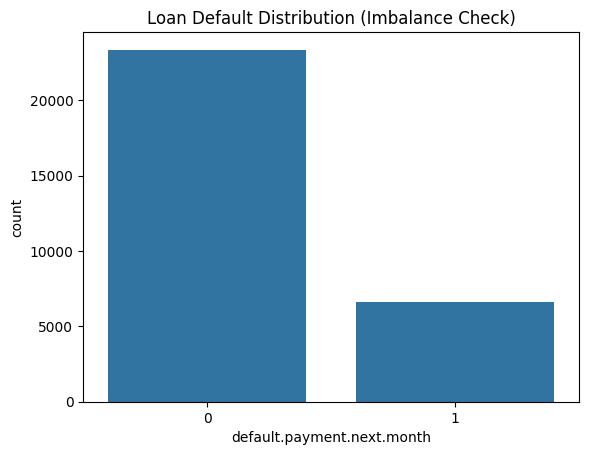

default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [ ]:
sns.countplot(x="default.payment.next.month", data=df)
plt.title("Loan Default Distribution (Imbalance Check)")
plt.show()

print(df["default.payment.next.month"].value_counts(normalize=True))

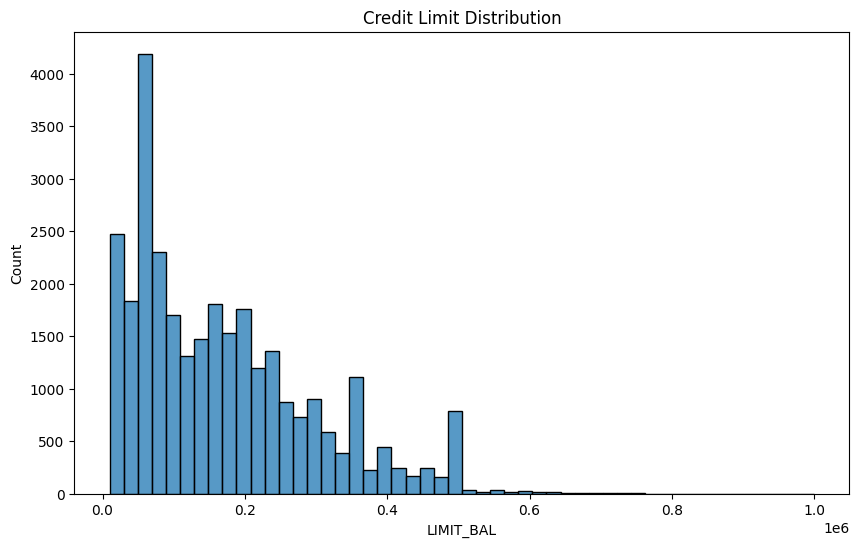

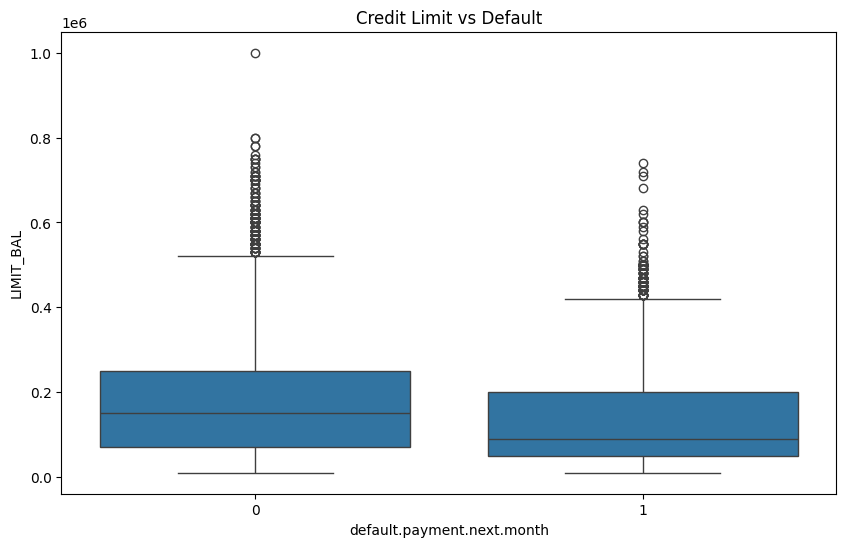

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df["LIMIT_BAL"], bins=50)
plt.title("Credit Limit Distribution")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x="default.payment.next.month", y="LIMIT_BAL", data=df)
plt.title("Credit Limit vs Default")
plt.show()

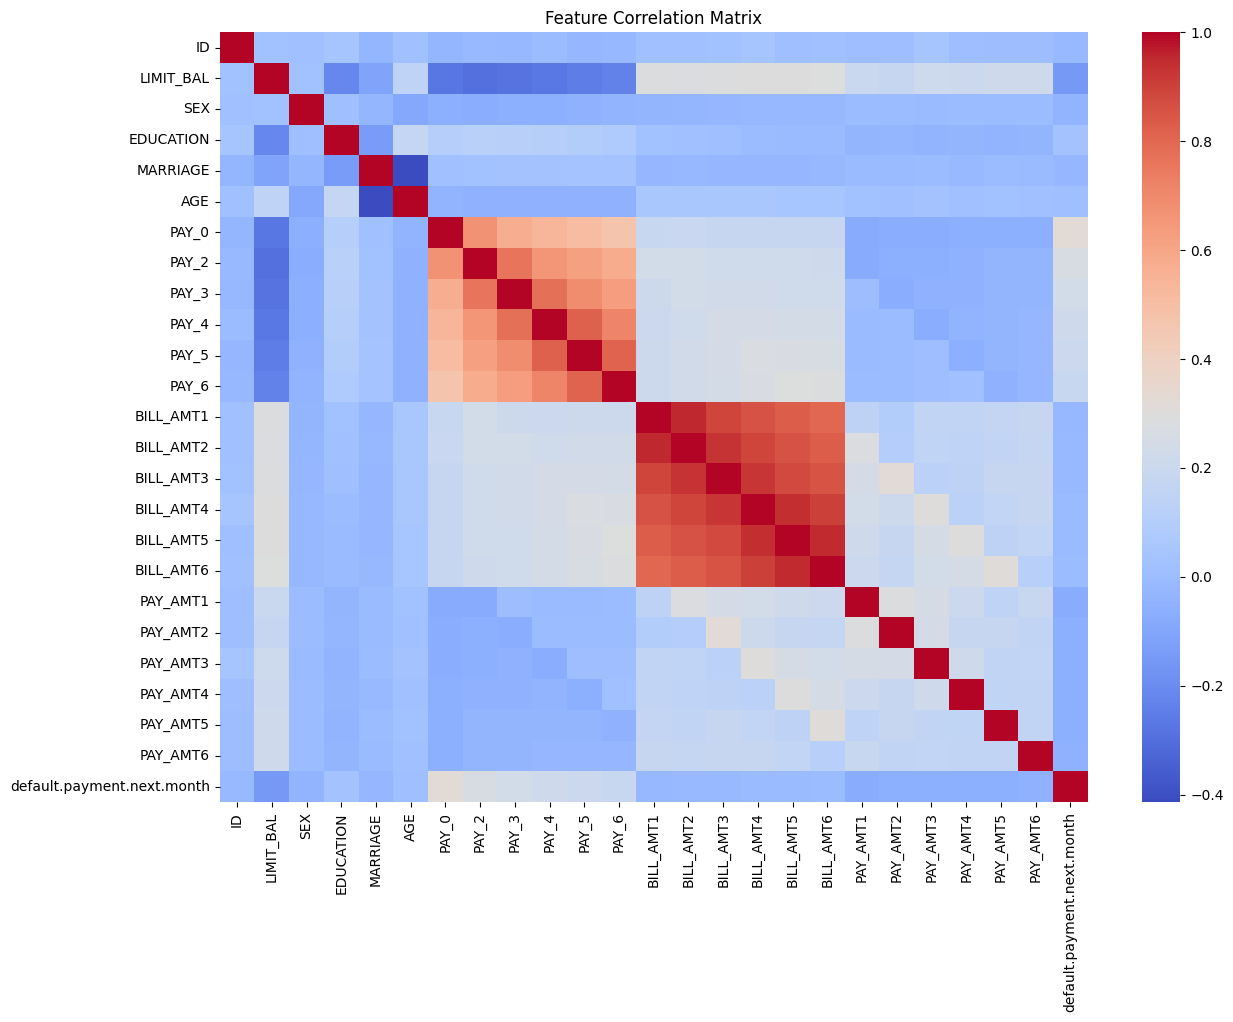

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
# Separate features and target
X = df.drop(["ID", "default.payment.next.month"], axis=1)
y = df["default.payment.next.month"]

# 1. Average Billing Amount
X["AVG_BILL"] = X[["BILL_AMT1","BILL_AMT2","BILL_AMT3",
                    "BILL_AMT4","BILL_AMT5","BILL_AMT6"]].mean(axis=1)

# 2. Average Payment Amount
X["AVG_PAY"] = X[["PAY_AMT1","PAY_AMT2","PAY_AMT3",
                   "PAY_AMT4","PAY_AMT5","PAY_AMT6"]].mean(axis=1)

# 3. Financial Stress Indicator
X["RISK_RATIO"] = X["AVG_BILL"] / (X["AVG_PAY"] + 1)

# Clean up
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

print("Missing values after feature engineering:", X.isnull().sum().sum())
print("Feature shape:", X.shape)

Missing values after feature engineering: 0
Feature shape: (30000, 26)


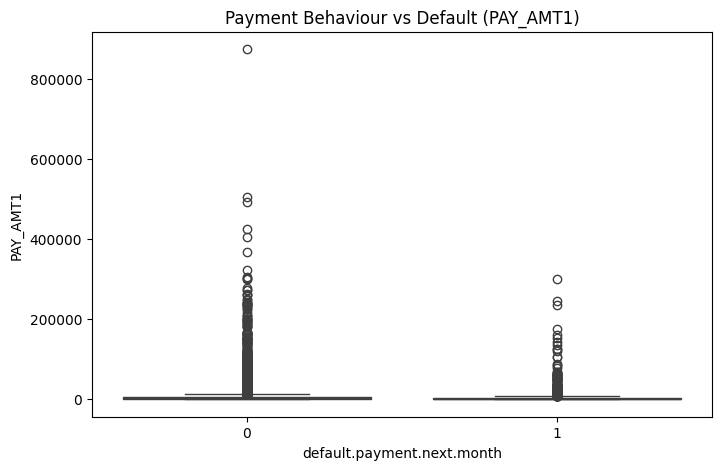

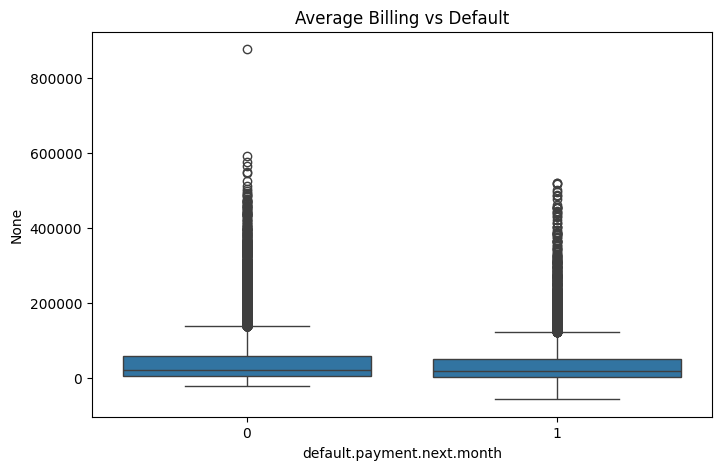

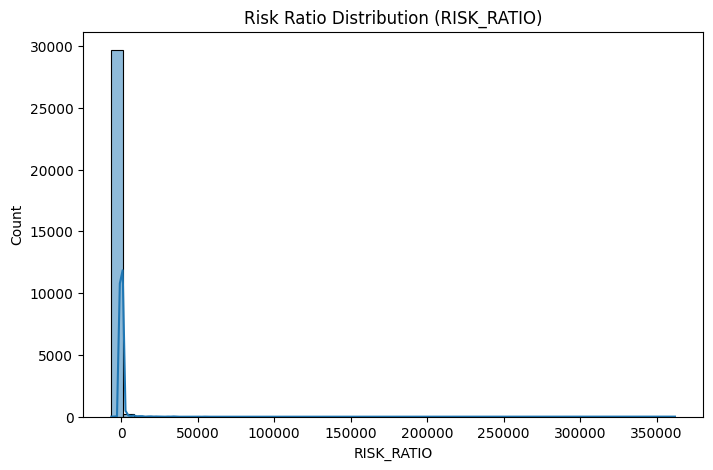

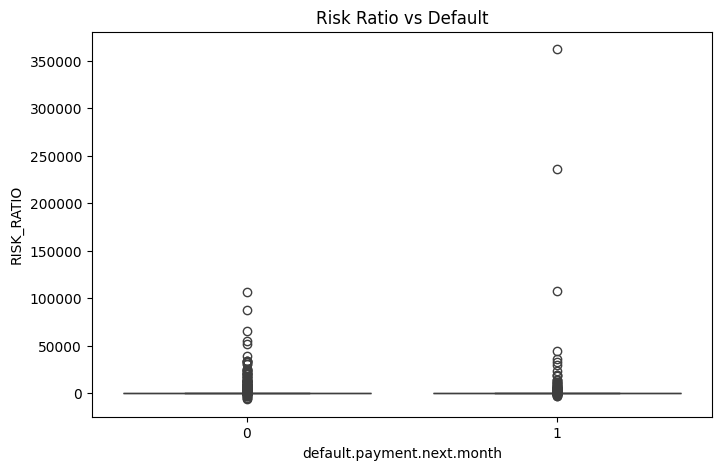

In [ ]:
# Payment behavior vs default
plt.figure(figsize=(8,5))
sns.boxplot(x=y, y=df["PAY_AMT1"])
plt.title("Payment Behaviour vs Default (PAY_AMT1)")
plt.show()

# Average billing vs default
avg_bill = df[["BILL_AMT1","BILL_AMT2","BILL_AMT3",
               "BILL_AMT4","BILL_AMT5","BILL_AMT6"]].mean(axis=1)
plt.figure(figsize=(8,5))
sns.boxplot(x=y, y=avg_bill)
plt.title("Average Billing vs Default")
plt.show()

# Risk Ratio distribution
plt.figure(figsize=(8,5))
sns.histplot(X["RISK_RATIO"], bins=50, kde=True)
plt.title("Risk Ratio Distribution (RISK_RATIO)")
plt.xlabel("RISK_RATIO")
plt.show()

# Risk Ratio vs Default
plt.figure(figsize=(8,5))
sns.boxplot(x=y, y=X["RISK_RATIO"])
plt.title("Risk Ratio vs Default")
plt.ylabel("RISK_RATIO")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Test set size:", X_test_scaled.shape)

Training set size: (24000, 26)
Test set size: (6000, 26)


In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression Accuracy: 0.6786666666666666
Logistic Regression ROC-AUC: 0.7079991504693303


In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:,1]

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

# Cross-validation
cv_scores = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring='roc_auc')
print(f"Cross-Validation ROC-AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

Random Forest Accuracy: 0.8136666666666666
Random Forest ROC-AUC: 0.7605058868056825
Cross-Validation ROC-AUC: 0.767 (+/- 0.006)


In [ ]:
print("Training SVM (this may take a few minutes)...")
svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42,
    cache_size=1000,
    class_weight="balanced"
)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:,1]

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

Training SVM (this may take a few minutes)...
SVM Accuracy: 0.777
SVM ROC-AUC: 0.7533379314637746


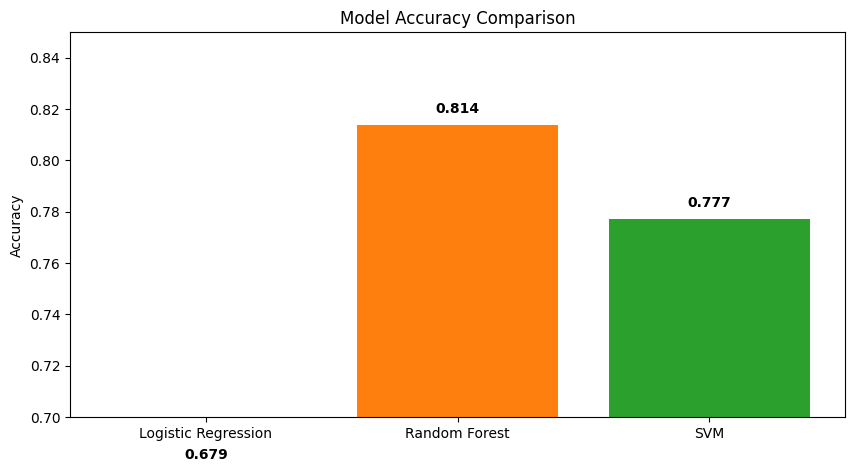

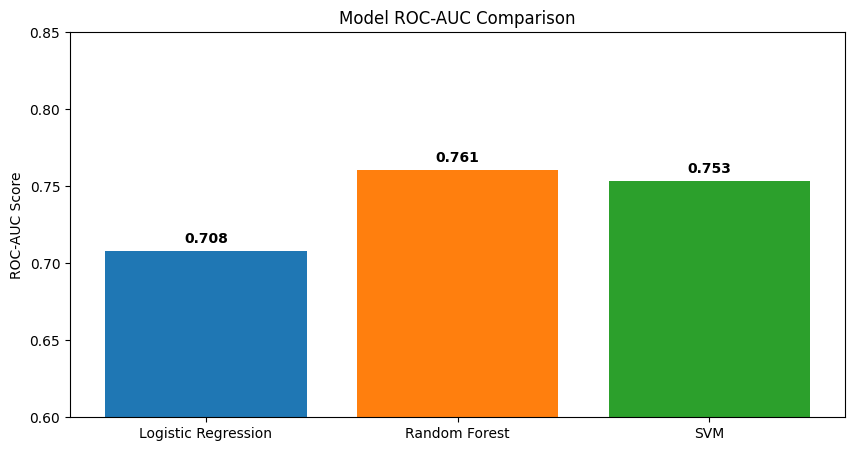

In [ ]:
models = ["Logistic Regression", "Random Forest", "SVM"]
accuracy_scores = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_svm)
]
roc_auc_scores = [
    roc_auc_score(y_test, y_prob_lr),
    roc_auc_score(y_test, y_prob_rf),
    roc_auc_score(y_test, y_prob_svm)
]

# Accuracy Plot
plt.figure(figsize=(10,5))
plt.bar(models, accuracy_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim([0.70, 0.85])
for i, v in enumerate(accuracy_scores):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')
plt.show()

# ROC-AUC Plot
plt.figure(figsize=(10,5))
plt.bar(models, roc_auc_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title("Model ROC-AUC Comparison")
plt.ylabel("ROC-AUC Score")
plt.ylim([0.60, 0.85])
for i, v in enumerate(roc_auc_scores):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')
plt.show()

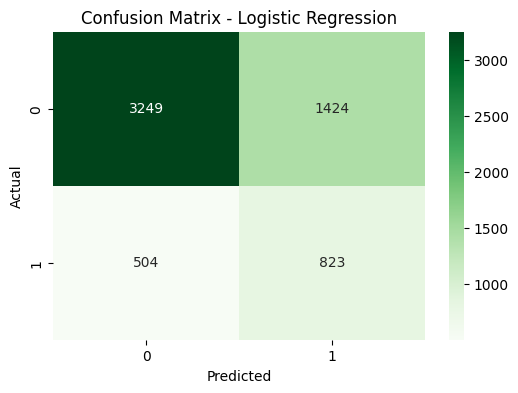

CLASSIFICATION REPORT - Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.70      0.77      4673
           1       0.37      0.62      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000



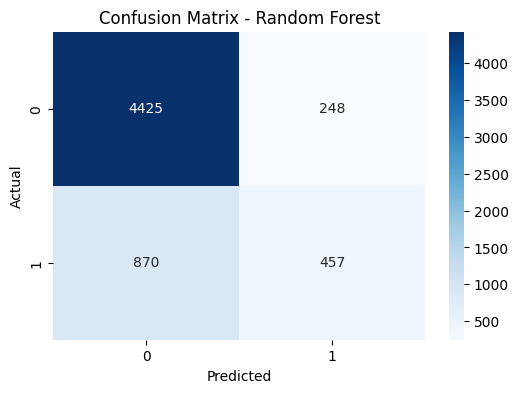

CLASSIFICATION REPORT - Random Forest
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.65      0.34      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000



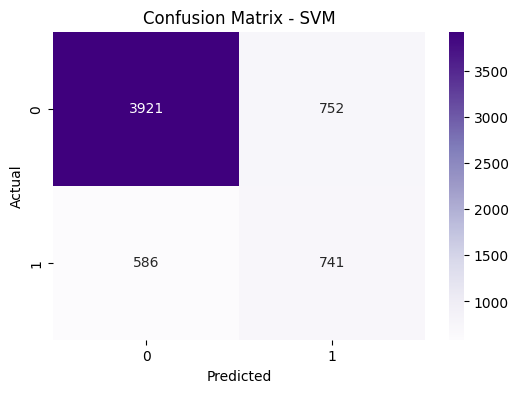

CLASSIFICATION REPORT - SVM
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      4673
           1       0.50      0.56      0.53      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.70      0.69      6000
weighted avg       0.79      0.78      0.78      6000



In [ ]:
# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("="*60)
print("CLASSIFICATION REPORT - Logistic Regression")
print("="*60)
print(classification_report(y_test, y_pred_lr))

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("="*60)
print("CLASSIFICATION REPORT - Random Forest")
print("="*60)
print(classification_report(y_test, y_pred_rf))

# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("="*60)
print("CLASSIFICATION REPORT - SVM")
print("="*60)
print(classification_report(y_test, y_pred_svm))

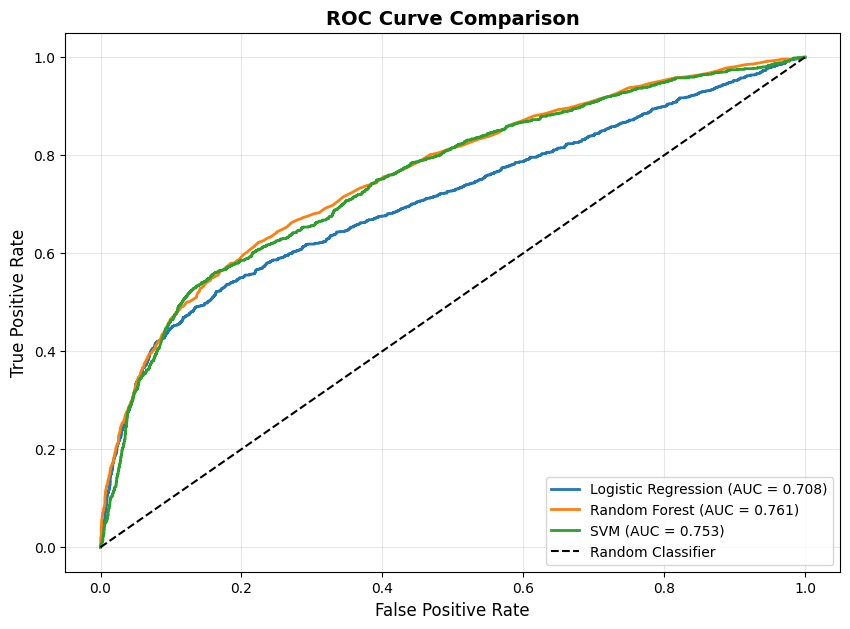

In [ ]:
plt.figure(figsize=(10,7))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})", linewidth=2)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})", linewidth=2)

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.3f})", linewidth=2)

plt.plot([0,1],[0,1],'k--', label="Random Classifier")
plt.title("ROC Curve Comparison", fontsize=14, fontweight='bold')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

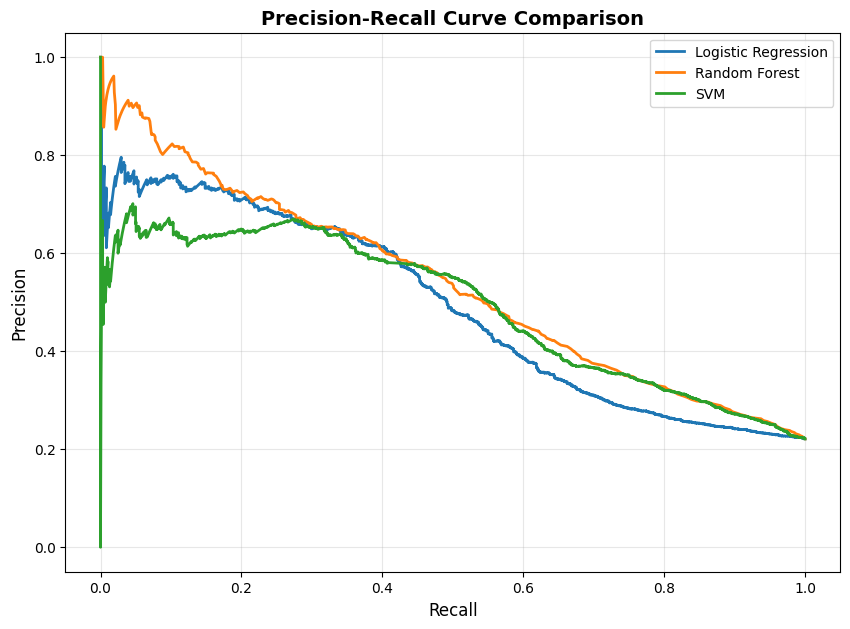

In [ ]:
plt.figure(figsize=(10,7))

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
plt.plot(recall_lr, precision_lr, label="Logistic Regression", linewidth=2)

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
plt.plot(recall_rf, precision_rf, label="Random Forest", linewidth=2)

precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_prob_svm)
plt.plot(recall_svm, precision_svm, label="SVM", linewidth=2)

plt.title("Precision-Recall Curve Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

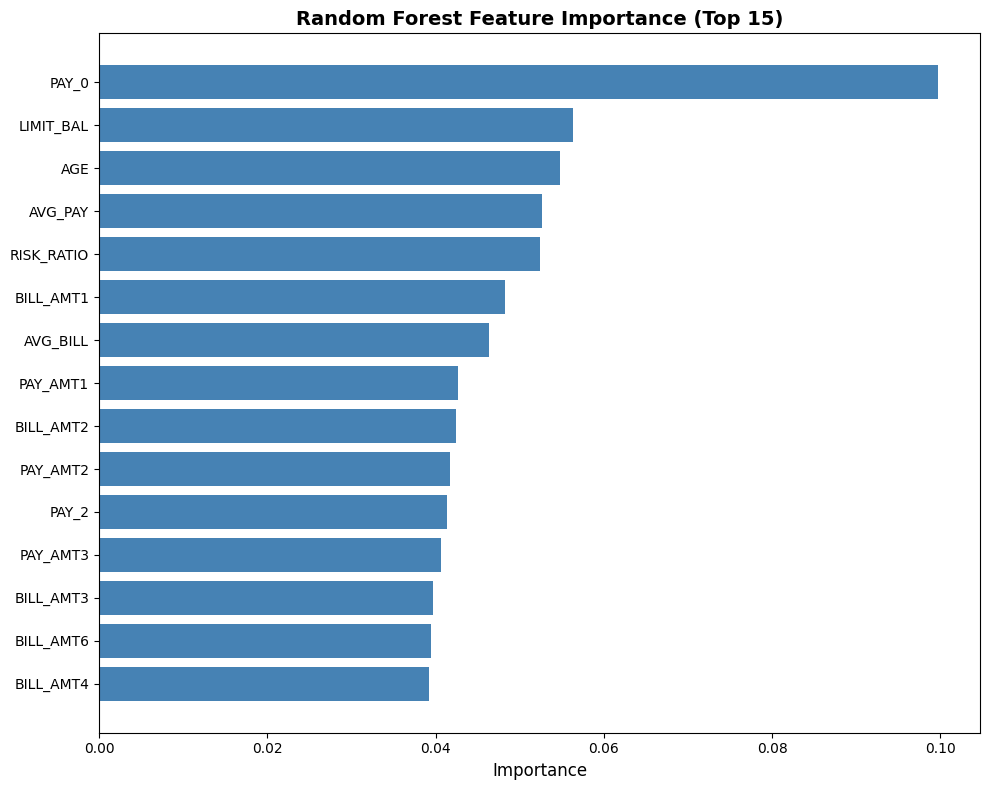


Top 10 Most Important Features:
       Feature  Importance
5        PAY_0    0.099708
0    LIMIT_BAL    0.056378
4          AGE    0.054785
24     AVG_PAY    0.052638
25  RISK_RATIO    0.052450
11   BILL_AMT1    0.048279
23    AVG_BILL    0.046376
17    PAY_AMT1    0.042651
12   BILL_AMT2    0.042442
18    PAY_AMT2    0.041705


In [ ]:
importances = rf.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,8))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance', fontsize=12)
plt.title('Random Forest Feature Importance (Top 15)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(importance_df.head(10))

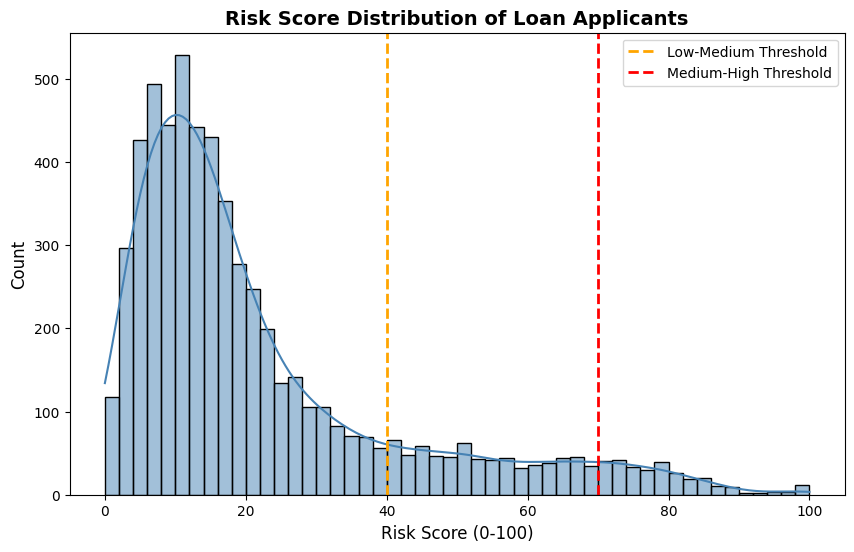

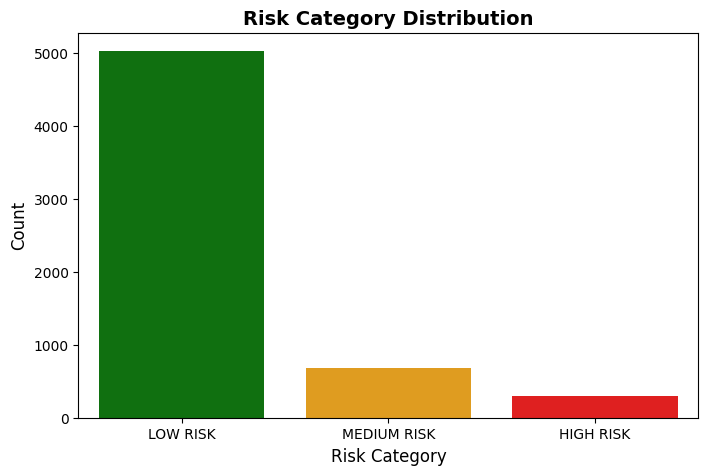


RISK DISTRIBUTION:
Risk_Category
LOW RISK       5023
MEDIUM RISK     685
HIGH RISK       292
Name: count, dtype: int64
Risk_Category
LOW RISK       0.837167
MEDIUM RISK    0.114167
HIGH RISK      0.048667
Name: proportion, dtype: float64


In [ ]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_rf,
    'Probability': y_prob_rf,
    'Risk_Score': y_prob_rf * 100
})

def risk_level(score):
    if score < 40:
        return "LOW RISK"
    elif score < 70:
        return "MEDIUM RISK"
    else:
        return "HIGH RISK"

results["Risk_Category"] = results["Risk_Score"].apply(risk_level)

plt.figure(figsize=(10,6))
sns.histplot(results["Risk_Score"], bins=50, kde=True, color='steelblue')
plt.axvline(x=40, color='orange', linestyle='--', linewidth=2, label='Low-Medium Threshold')
plt.axvline(x=70, color='red', linestyle='--', linewidth=2, label='Medium-High Threshold')
plt.title("Risk Score Distribution of Loan Applicants", fontsize=14, fontweight='bold')
plt.xlabel("Risk Score (0-100)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x="Risk_Category", hue="Risk_Category", data=results,
              order=["LOW RISK","MEDIUM RISK","HIGH RISK"],
              palette={'LOW RISK':'green','MEDIUM RISK':'orange','HIGH RISK':'red'},
              legend=False)
plt.title("Risk Category Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Risk Category", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

print("\nRISK DISTRIBUTION:")
print(results["Risk_Category"].value_counts())
print(results["Risk_Category"].value_counts(normalize=True))

In [ ]:
print("="*60)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("="*60)

print("\nACCURACY SCORES:")
print(f"  Logistic Regression : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  Random Forest       : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  SVM (RBF Kernel)    : {accuracy_score(y_test, y_pred_svm):.4f}")

print("\nROC-AUC SCORES:")
print(f"  Logistic Regression : {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"  Random Forest       : {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"  SVM (RBF Kernel)    : {roc_auc_score(y_test, y_prob_svm):.4f}")

print("\nBEST MODEL: Random Forest")
print(f"  Cross-Val ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

print("\nTOP 3 FEATURES:")
for i, row in importance_df.head(3).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

print("\nRISK DISTRIBUTION:")
print(results["Risk_Category"].value_counts())
print("="*60)

FINAL MODEL PERFORMANCE SUMMARY

ACCURACY SCORES:
  Logistic Regression : 0.6787
  Random Forest       : 0.8137
  SVM (RBF Kernel)    : 0.7770

ROC-AUC SCORES:
  Logistic Regression : 0.7080
  Random Forest       : 0.7605
  SVM (RBF Kernel)    : 0.7533

BEST MODEL: Random Forest
  Cross-Val ROC-AUC: 0.7674 (+/- 0.0055)

TOP 3 FEATURES:
  PAY_0: 0.0997
  LIMIT_BAL: 0.0564
  AGE: 0.0548

RISK DISTRIBUTION:
Risk_Category
LOW RISK       5023
MEDIUM RISK     685
HIGH RISK       292
Name: count, dtype: int64
